In [12]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

from src.logger import setup_logging, get_logger
from src.db import load_missions_full
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
setup_logging()
log = get_logger(__name__)

df = load_missions_full()

06:03:48  INFO      load_missions_full → 10,500 rows


In [2]:


plt.rcParams.update({
    "figure.facecolor":  "white",
    "axes.facecolor":    "white",
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "axes.grid":         True,
    "grid.color":        "#e5e5e5",
    "grid.linewidth":    0.7,
    "font.size":         11,
})

In [3]:
print(f"Total missions:      {len(df):,}")
print(f"Unique agencies:     {df['agency_name'].nunique()}")
print(f"Unique countries:    {df['country_region'].nunique()}")
print(f"Year range:          {df['launch_year'].min()} — {df['launch_year'].max()}")
print(f"Crewed missions:     {(df['crew_type']=='Crewed').sum():,}")
print(f"Uncrewed missions:   {(df['crew_type']=='Uncrewed').sum():,}")
print(f"\nStatus breakdown:")
print(df["status"].value_counts(normalize=True).mul(100).round(2).astype(str) + "%")

Total missions:      10,500
Unique agencies:     27
Unique countries:    10
Year range:          1957 — 2035
Crewed missions:     2,637
Uncrewed missions:   7,863

Status breakdown:
status
Success            41.09%
Ongoing            29.94%
Upcoming           14.86%
Failed              8.66%
Partial Success     5.46%
Name: proportion, dtype: object


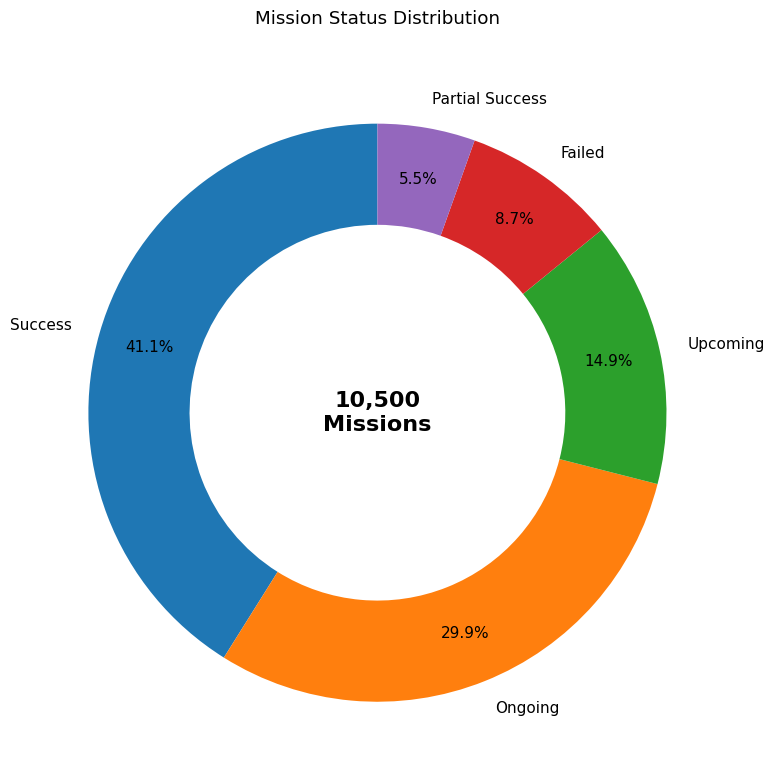

In [4]:
status_counts = df["status"].value_counts()

fig, ax = plt.subplots(figsize=(8, 8))

ax.pie(
    status_counts.values,
    labels=status_counts.index,
    autopct=lambda p: f"{p:.1f}%",
    startangle=90,
    pctdistance=0.82,
    wedgeprops=dict(width=0.35)
)


ax.text(
    0, 0,
    f"{status_counts.sum():,}\nMissions",
    ha="center",
    va="center",
    fontsize=16,
    fontweight="bold"
)

ax.set_title("Mission Status Distribution", pad=20)

plt.tight_layout()
plt.show()

In [5]:
agency_summary = df.groupby("agency_name").agg(
    total_missions=("mission_id", "count"),
    successful_missions=("status", lambda x: (x == "Success").sum()),
    failed_missions=("status", lambda x: (x == "Failed").sum()),
    upcoming_missions=("status", lambda x: (x == "Upcoming").sum()),
    ongoing_missions=("status", lambda x: (x == "Ongoing").sum()),
    partially_successful_missions=("status", lambda x: (x == "Partial Success").sum()),
    avg_cost_million=("cost_usd_million", lambda x: round(x.mean(), 2)),
    total_cost_million=("cost_usd_million", "sum"),
    avg_duration_days=("duration_days", lambda x: round(x.mean(), 2)),
    agency_type=("agency_type", lambda x: x.mode()[0] if not x.mode().empty else "Unknown"),
    crewed_missions=("crew_type", lambda x: (x == "Crewed").sum()),).reset_index()

agency_summary["success_rate"] = (agency_summary["successful_missions"] / agency_summary["total_missions"] * 100).round(2)



agency_summary = agency_summary[agency_summary["total_missions"] > 5]

agency_summary["cost_per_success"] = (
    pd.to_numeric(agency_summary["total_cost_million"]) / agency_summary["successful_missions"]).round(2)

agency_summary["success_rate"] = agency_summary["success_rate"].apply(lambda x: f"{x:.2f}%")

agency_summary.reset_index(drop=True, inplace=True)
agency_summary

,agency_name,total_missions,successful_missions,failed_missions,upcoming_missions,ongoing_missions,partially_successful_missions,avg_cost_million,total_cost_million,avg_duration_days,agency_type,crewed_missions,success_rate,cost_per_success
0,ASI,816,325,73,116,255,47,7521.00,6137139.30,2549.44,Government,207,39.83%,18883.51
1,Blue Origin,856,364,64,118,262,48,7397.88,6332585.30,2505.43,Private,223,42.52%,17397.21
2,CNES,812,310,74,125,255,48,7434.69,6036969.50,2512.63,Government,206,38.18%,19474.10
3,CNSA,904,376,63,152,269,44,7281.40,6582385.50,2483.38,Government,206,41.59%,17506.34
4,CSA,777,315,64,125,236,37,7480.57,5812402.30,2570.99,Government,194,40.54%,18452.07
5,DLR,849,343,82,133,244,47,7367.65,6255138.80,2603.51,Government,229,40.40%,18236.56
6,ESA,891,357,80,143,272,39,7571.05,6745809.60,2503.36,Government,242,40.07%,18895.83
7,ISRO,840,354,88,118,231,49,7514.46,6312146.80,2464.44,Government,214,42.14%,17830.92
8,JAXA,890,372,80,142,248,48,7218.55,6424511.10,2612.79,Government,230,41.80%,17270.19
9,NASA,973,392,86,135,299,61,7153.29,6960146.90,2596.59,Government,220,40.29%,17755.48


In [19]:
# One colour per agency 
PALETTE = [
    "#378ADD","#E24B4A","#1D9E75","#EF9F27","#534AB7",
    "#D4537E","#639922","#BA7517","#D85A30","#888780","#5DCAA5","#7A5AF8"
]
color_map = dict(zip(agency_summary["agency_name"], PALETTE))


In [7]:
agency_summary.sort_values("total_missions", ascending=False,inplace=True)

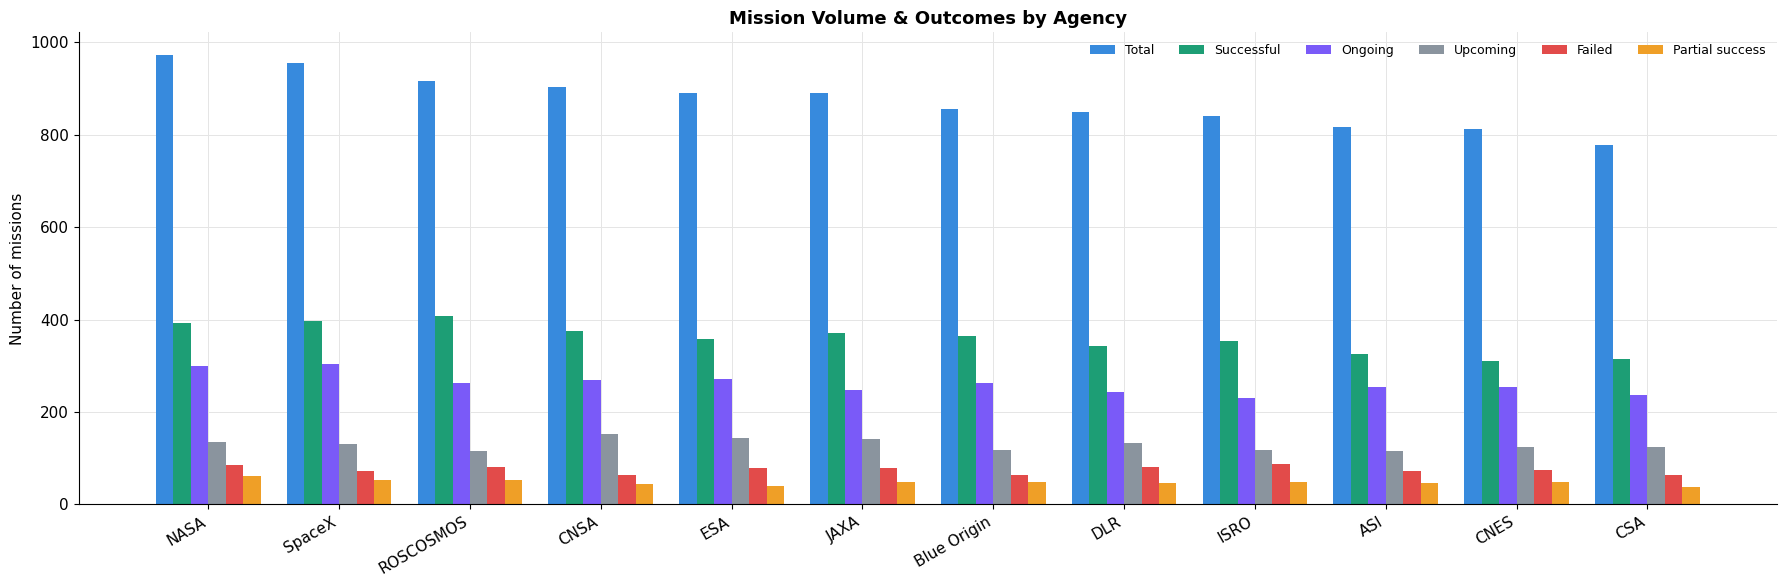

In [8]:
groups = [
    ("total_missions",                "Total",           "#378ADD"),
    ("successful_missions",           "Successful",      "#1D9E75"),
    ("ongoing_missions",              "Ongoing",         "#7A5AF8"),
    ("upcoming_missions",             "Upcoming",        "#8A949E"),
    ("failed_missions",               "Failed",          "#E24B4A"),
    ("partially_successful_missions", "Partial success", "#EF9F27"),
]

#these are derived values, not hardcoded, so the code is more robust to changes in the groups list
n_groups   = len(groups)                          
n_agencies = len(agency_summary)                  

# width of each bar within a cluster, derived from total cluster width and number of bars
cluster_width = 0.80
w = cluster_width / n_groups                      


fig, ax = plt.subplots(figsize=(max(18, n_agencies * 1.4), 6))

#x positions for each agency cluster
x = np.arange(n_agencies)

for i, (col, label, colour) in enumerate(groups):
    offset = (i - (n_groups - 1) / 2) * w
    ax.bar(x + offset, agency_summary[col],
           width=w, label=label, color=colour, edgecolor="none")

ax.set_title("Mission Volume & Outcomes by Agency", fontsize=13, fontweight="bold")
ax.set_xticks(x)
#changing the labels back to the agency names, rotated for readability
ax.set_xticklabels(agency_summary["agency_name"], rotation=30, ha="right")
ax.set_ylabel("Number of missions")
ax.legend(frameon=False, ncol=6, loc="upper right", fontsize=9)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

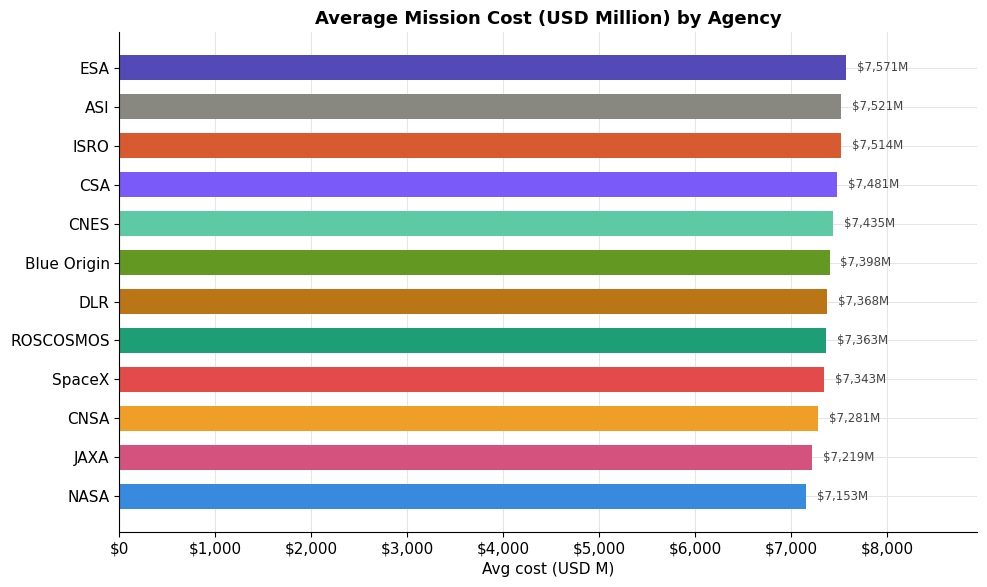

In [11]:
df_cost = agency_summary.sort_values("avg_cost_million")

fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.barh(
    df_cost["agency_name"],
    df_cost["avg_cost_million"],
    color=[color_map[a] for a in df_cost["agency_name"]],
    edgecolor="none",
    height=0.65,
)
for bar, val in zip(bars, df_cost["avg_cost_million"]):
    ax.text(
        val + (df_cost["avg_cost_million"].max() * 0.015),
        bar.get_y() + bar.get_height() / 2,
        f"${val:,.0f}M",
        va="center", ha="left", fontsize=8.5, color="#444",
    )

ax.set_title("Average Mission Cost (USD Million) by Agency", fontsize=13, fontweight="bold")
ax.set_xlabel("Avg cost (USD M)")
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"${int(v):,}"))
ax.set_xlim(0, df_cost["avg_cost_million"].max() * 1.18)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

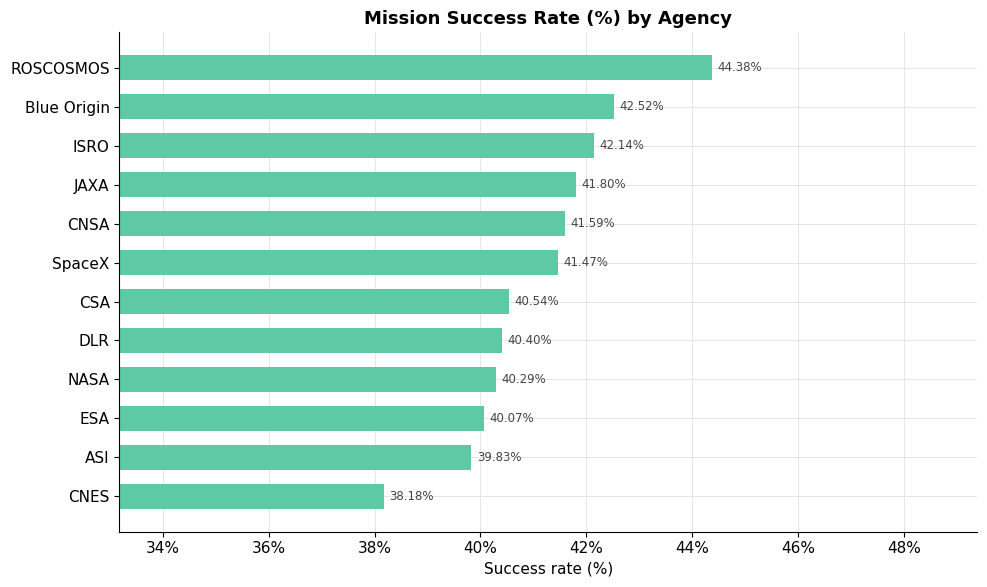

In [16]:

df_sr = agency_summary.copy()
df_sr["success_rate_num"] = df_sr["success_rate"].str.replace("%", "").astype(float)
df_sr = df_sr.sort_values("success_rate_num")


fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.barh(
    df_sr["agency_name"],
    df_sr["success_rate_num"],
    color="#5DCAA5",
    edgecolor="none",
    height=0.65,
)
for bar, val in zip(bars, df_sr["success_rate_num"]):
    ax.text(
        val + 0.1,
        bar.get_y() + bar.get_height() / 2,
        f"{val:.2f}%",
        va="center", ha="left", fontsize=8.5, color="#444",
    )

ax.set_title("Mission Success Rate (%) by Agency", fontsize=13, fontweight="bold")
ax.set_xlabel("Success rate (%)")
ax.set_xlim(
    df_sr["success_rate_num"].min() - 5,
    df_sr["success_rate_num"].max() + 5,
)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0f}%"))
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

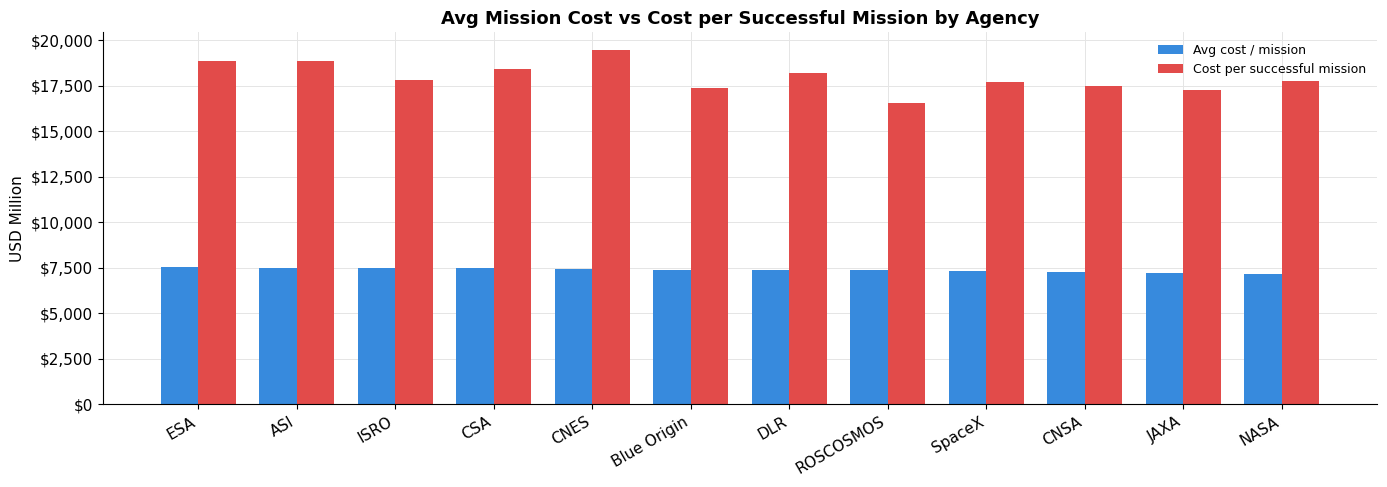

In [23]:
df_bp = agency_summary[["agency_name", "avg_cost_million", "cost_per_success"]].copy()
df_bp = df_bp.sort_values("avg_cost_million", ascending=False)

x = np.arange(len(df_bp))
w = 0.38

fig, ax = plt.subplots(figsize=(14, 5))

ax.bar(x - w / 2, df_bp["avg_cost_million"],
       width=w, color="#378ADD", edgecolor="none", label="Avg cost / mission")
ax.bar(x + w / 2, df_bp["cost_per_success"],
       width=w, color="#E24B4A", edgecolor="none", label="Cost per successful mission")

ax.set_title("Avg Mission Cost vs Cost per Successful Mission by Agency",
             fontsize=13, fontweight="bold")
ax.set_xticks(x)
ax.set_xticklabels(df_bp["agency_name"], rotation=30, ha="right")
ax.set_ylabel("USD Million")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"${int(v):,}"))
ax.legend(frameon=False, fontsize=9)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

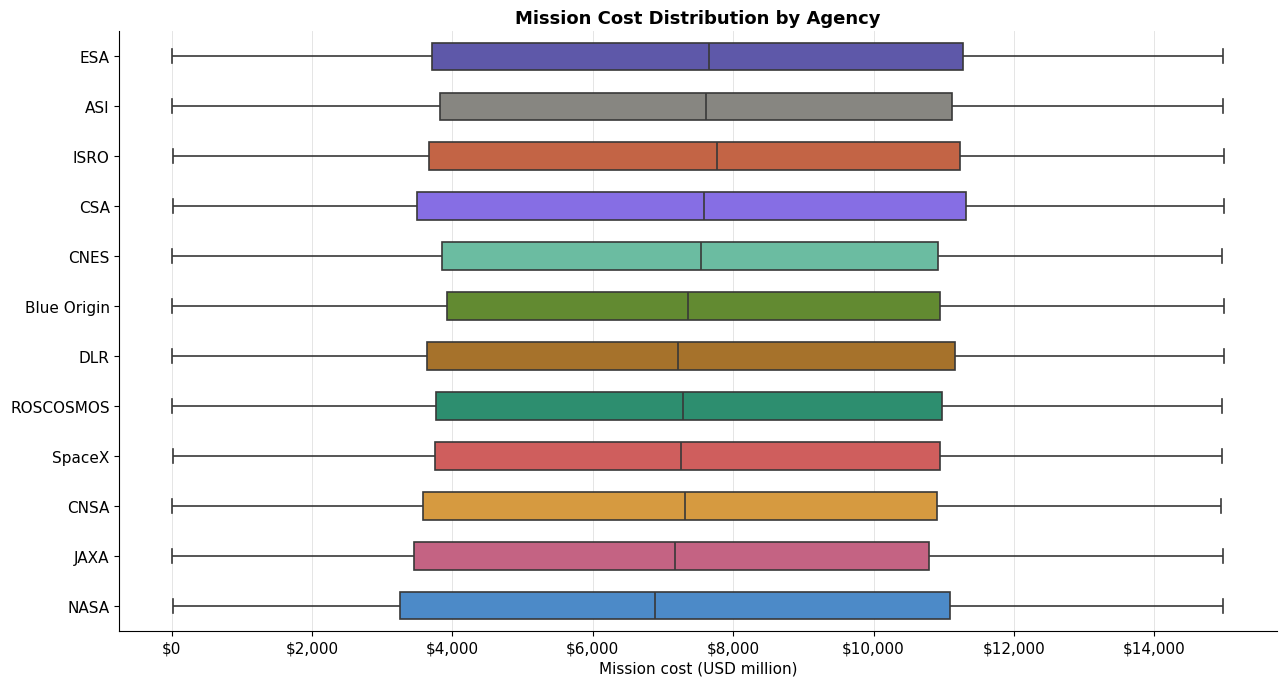

In [34]:
order = (
    agency_summary
    .sort_values("avg_cost_million", ascending=False)["agency_name"]
    .tolist()
)

df_b = df.copy()
df_b = df_b[df_b["agency_name"].isin(agency_summary["agency_name"])].copy()

fig, ax = plt.subplots(figsize=(13, 7))

sns.boxplot(
    data=df_b,
    x="cost_usd_million",
    y="agency_name",
    hue="agency_name",
    order=order,
    palette=color_map,
    width=0.55,
    linewidth=1.2,
    fliersize=2.5,
    flierprops=dict(marker="o", alpha=0.3),
    legend=False,
    ax=ax,
)

ax.set_title("Mission Cost Distribution by Agency", fontsize=13, fontweight="bold")
ax.set_xlabel("Mission cost (USD million)")
ax.set_ylabel("")
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"${int(v):,}"))
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

In [40]:
category_summary = df.groupby("mission_category").agg(
    total_missions=("mission_id", "count"),
    success_rate=("status", lambda x: (x == "Success").mean() * 100),
    failure_rate=("status", lambda x: (x == "Failed").mean() * 100),
    avg_cost_million=("cost_usd_million", lambda x: round(x.mean(), 2)),
)

In [41]:
category_summary.reset_index(inplace=True)
category_summary.sort_values("total_missions", ascending=False, inplace=True)
category_summary

,mission_category,total_missions,success_rate,failure_rate,avg_cost_million
10,Mercury,597,41.876047,8.040201,7722.44
4,Deep Space,582,44.158076,7.216495,7687.80
13,SmallSat,579,41.968912,8.462867,7297.94
12,Saturn,575,42.260870,8.869565,6953.66
11,Moon,571,42.031524,10.332750,7594.75
9,Mars,564,37.234043,7.978723,7493.92
1,Communication Satellite,563,41.207815,11.190053,7431.71
17,Telescope,559,38.282648,7.334526,7315.56
2,Crewed Spaceflight,559,40.071556,11.091234,6986.39
3,CubeSat,559,40.429338,8.586762,7422.77
